# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Data Curation Part 2

Today we'll extend our dataset to a greater coverage, and craft it into an excellent dataset for training.

The dataset is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

## The Lite dataset

This notebook is an alternative to `day2.ipynb` that creates a smaller dataset for Home Appliances only, to keep training fast and costs low. You may need to update names of future notebooks to reflect that you have built the "lite" dataset not the full dataset.

In [1]:
# imports

import os
import random
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
from items import Item
from loaders import ItemLoader
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
import pickle

In [2]:
# environment

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

In [3]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [4]:
%matplotlib inline

## The ItemLoader code

Look in loaders.py - there's some useful code to make life easier for us

## Now to SCALE UP

Let's look at all datasets of all the items that you might find in a large home retail store - electrical, electronic, office and related, but not clothes / beauty / books.

In [5]:
dataset_names = [
    "Automotive",
    # "Electronics",
    # "Office_Products",
    # "Tools_and_Home_Improvement",
    # "Cell_Phones_and_Accessories",
    # "Toys_and_Games",
    "Software",
    "Health_and_Personal_Care",
    "Appliances",
    "Musical_Instruments",
]

In [6]:
items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())


Loading dataset Automotive


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 2004/2004 [34:40<00:00,  1.04s/it]


Completed Automotive with 911,688 datapoints in 34.9 mins

Loading dataset Software


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 90/90 [13:51<00:00,  9.23s/it]


Completed Software with 14,635 datapoints in 14.0 mins

Loading dataset Health_and_Personal_Care


...

Completed Health_and_Personal_Care with 4,591 datapoints in 2.2 mins

Loading dataset Appliances


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 95/95 [01:20<00:00,  1.19it/s]


Completed Appliances with 28,625 datapoints in 2.8 mins

Loading dataset Musical_Instruments


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 214/214 [02:28<00:00,  1.44it/s]


Completed Musical_Instruments with 66,829 datapoints in 4.0 mins


In [8]:
print(f"A grand total of {len(items):,} items")

A grand total of 1,026,368 items


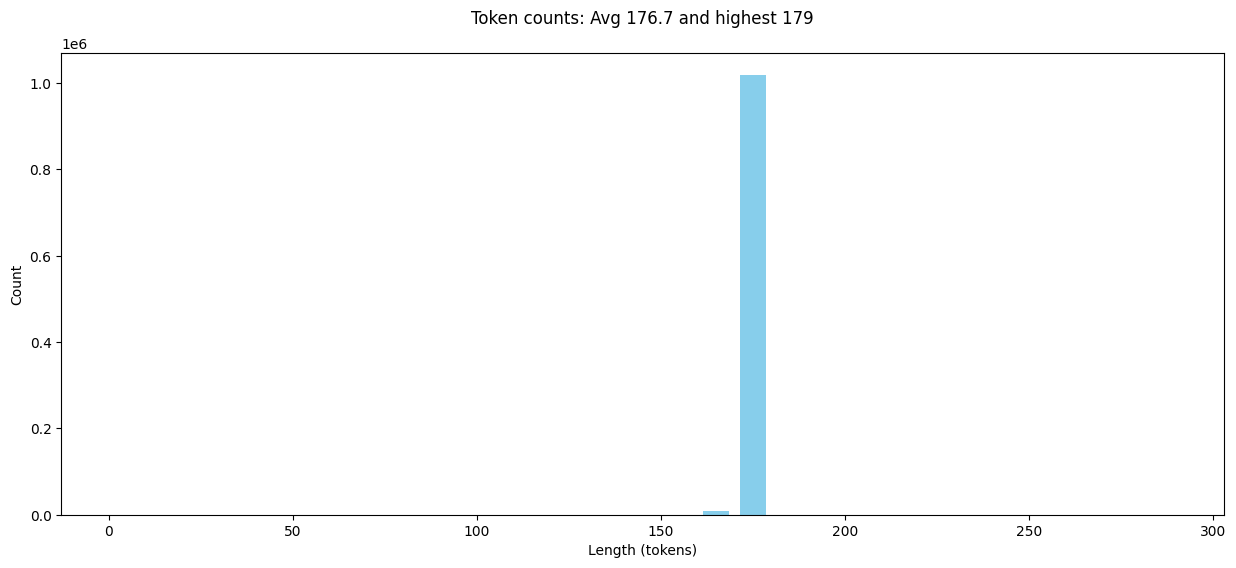

In [9]:
# Plot the distribution of token counts again

tokens = [item.token_count for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Token counts: Avg {sum(tokens)/len(tokens):,.1f} and highest {max(tokens):,}\n")
plt.xlabel('Length (tokens)')
plt.ylabel('Count')
plt.hist(tokens, rwidth=0.7, color="skyblue", bins=range(0, 300, 10))
plt.show()

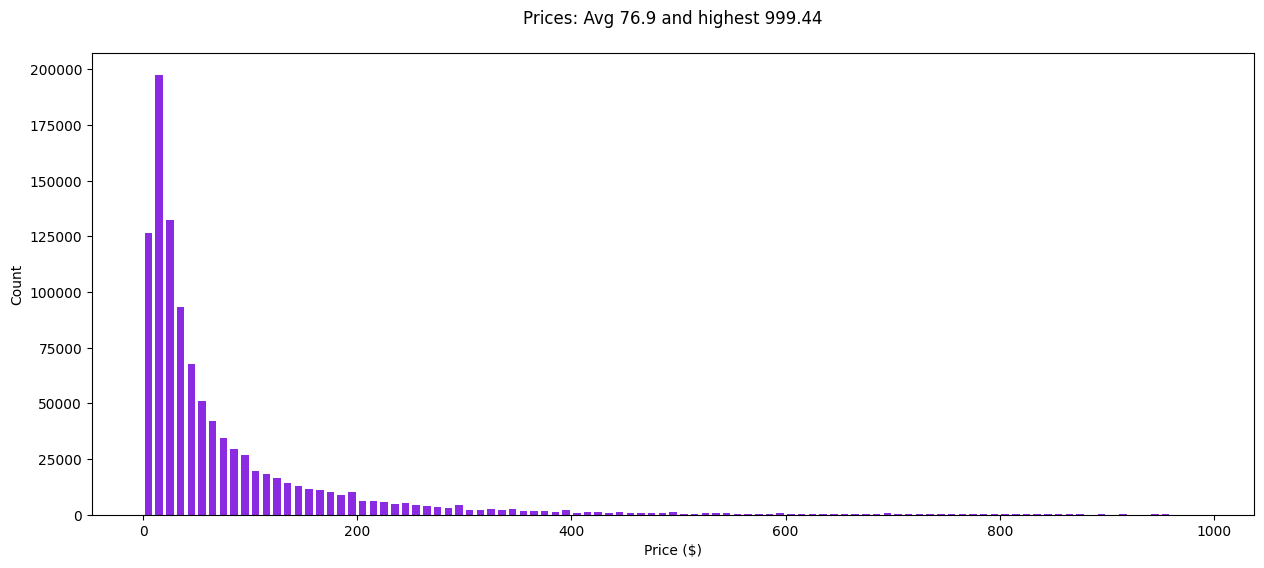

In [10]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="blueviolet", bins=range(0, 1000, 10))
plt.show()

# Dataset Curated!

We've crafted an excellent dataset.

Let's do some final checks

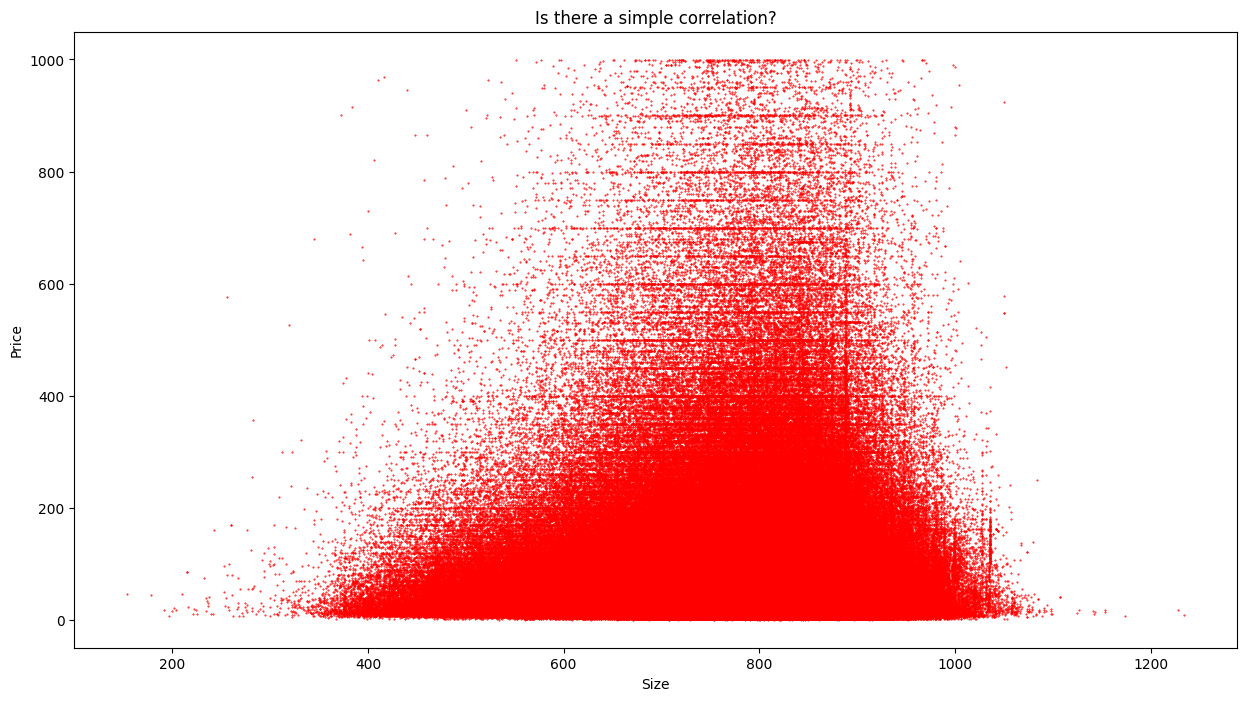

In [11]:
# How does the price vary with the character count of the prompt?

sample = items

sizes = [len(item.prompt) for item in sample]
prices = [item.price for item in sample]

# Create the scatter plot
plt.figure(figsize=(15, 8))
plt.scatter(sizes, prices, s=0.2, color="red")

# Add labels and title
plt.xlabel('Size')
plt.ylabel('Price')
plt.title('Is there a simple correlation?')

# Display the plot
plt.show()

In [12]:
def report(item):
    prompt = item.prompt
    tokens = Item.tokenizer.encode(item.prompt)
    print(prompt)
    print(tokens[-10:])
    print(Item.tokenizer.batch_decode(tokens[-10:]))

In [13]:
report(sample[50])

How much does this cost to the nearest dollar?

Lower Undercar Engine Shield Cover - Compatible with Ford Fusion 1.5L 1.6L 2.0L 2.5L FWD
Lower Undercar Engine Shield Cover - Compatible with 2013 - 2020 Ford Fusion 1.5L 1.6L 2.0L 2.5L FWDNote UNDERCAR SHIELD; FITS AND 2.0L FWD ENGINES; MADE AT HERMOSILLA PLANTQuality Capa Certified - Ensures the part fits, performs, and lasts the same as the original.Compatible With or Fits - 2013 - 2020 Ford Fusion - 2013 - 2020 Ford Fusion Energi - 2013 - 2020 Ford Fusion

Price is $165.00
[15, 14337, 43337, 271, 7117, 374, 400, 10680, 13, 410]
['0', ' Ford', ' Fusion', '\n\n', 'Price', ' is', ' $', '165', '.', '00']


## Observation

An interesting thing about the Llama tokenizer is that every number from 1 to 999 gets mapped to 1 token, much as we saw with gpt-4o. The same is not true of qwen2, gemma and phi3, which all map individual digits to tokens. This does turn out to be a bit useful for our project, although it's not an essential requirement.

# Finally

It's time to break down our data into a training, test and validation dataset.

It's typical to use 5%-10% of your data for testing purposes, but actually we have far more than we need at this point. We'll take 25,000 points for training, and we'll reserve 2,000 for testing, although we won't use all of them.


In [14]:
random.seed(42)
random.shuffle(sample)
train = sample[:25_000]
test = sample[25_000:27_000]
print(f"Divided into a training set of {len(train):,} items and test set of {len(test):,} items")

Divided into a training set of 25,000 items and test set of 2,000 items


In [15]:
print(train[0].prompt)

How much does this cost to the nearest dollar?

AKKON - Fits 2013 2014 Subaru Legacy | Outback Projector Chrome Headlights HeadLamp Driver Left+Passenger Right
This is a 100% brand new pair of Replacement Headlights in Chrome Housing Clear Lens Compatible With Subaru Subaru Outback 100% Brand New in Box With Customized Packaging Never Been Installed Before Comes in a Pair Which Means Included Left Side (Driver Side) & Right Side (Passenger Side) Direct Bolt On Replacement For Your Original Headlights No Wiring or Any Other Modification Needed DOT (Department of Transportation) & SAE (Society of Automotive Engineers) Approved No Installation Guide or Instruction Included Professional Installation is Highly Recommended Brand AKKON, Weight 29.5 pounds, Dimensions 31 x 20 x 14 inches, Manufacturer Part

Price is $175.00


In [16]:
print(test[0].test_prompt())

How much does this cost to the nearest dollar?

Greer Amps Lamplighter Optical Compressor
Greer Amps Lamplighter Optical Compressor The very idea for the Lamplighter Optical Compressor is rooted in legendary tone and studio lore. The Lamplighter is the result of countless hours of tweaking, listening, and tweaking again. The idea is pretty simpleâ€”provide compression that doesnâ€t â€œstepâ€ on your tone like other compressors do, make it as transparent as possible, with a low noise floor, while allowing the effect to be present, and provide options that musicians the world over have asked for. This is Greer Ampsâ€ answer to the question of wide-ranging, useable compression for all musicians. After listening to studio compressors for years, weâ€ve often

Price is $


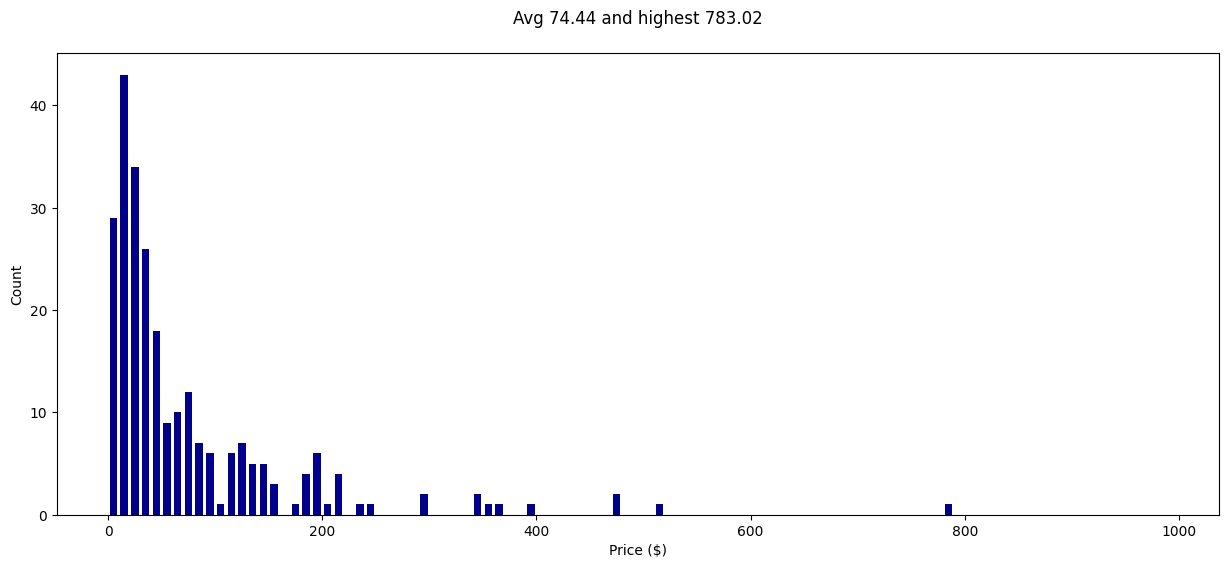

In [17]:
# Plot the distribution of prices in the first 250 test points

prices = [float(item.price) for item in test[:250]]
plt.figure(figsize=(15, 6))
plt.title(f"Avg {sum(prices)/len(prices):.2f} and highest {max(prices):,.2f}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="darkblue", bins=range(0, 1000, 10))
plt.show()

# Finally - upload your brand new dataset

Convert to prompts and upload to HuggingFace hub

In [18]:
train_prompts = [item.prompt for item in train]
train_prices = [item.price for item in train]
test_prompts = [item.test_prompt() for item in test]
test_prices = [item.price for item in test]

In [19]:
# Create a Dataset from the lists

train_dataset = Dataset.from_dict({"text": train_prompts, "price": train_prices})
test_dataset = Dataset.from_dict({"text": test_prompts, "price": test_prices})
dataset = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

In [21]:
DATASET_NAME = "christseng898/lite-data"
dataset.push_to_hub(DATASET_NAME, private=True)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/25 [00:00<?, ?ba/s]

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

D:\development\llm_engineering\venv\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\samfi\.cache\huggingface\hub\datasets--christseng898--lite-data. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


CommitInfo(commit_url='https://huggingface.co/datasets/christseng898/lite-data/commit/d6935d48413f79dcf57aa42289dd52f6616c3028', commit_message='Upload dataset', commit_description='', oid='d6935d48413f79dcf57aa42289dd52f6616c3028', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/christseng898/lite-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='christseng898/lite-data'), pr_revision=None, pr_num=None)

In [22]:
# One more thing!
# Let's pickle the training and test dataset so we don't have to execute all this code next time!

with open('train_lite.pkl', 'wb') as file:
    pickle.dump(train, file)

with open('test_lite.pkl', 'wb') as file:
    pickle.dump(test, file)

## Todos for you:

- Investigate the dataset more!
- Confirm that the tokenizer tokenizes all 3 digit prices into 1 token

In [24]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sample_prices = ["100", "249", "999"]
tokenized_prices = {price: tokenizer.tokenize(price) for price in sample_prices}
print(tokenized_prices)


{'100': ['100'], '249': ['249'], '999': ['999']}


### Investigate the dataset more!

In [27]:
from datasets import load_dataset, get_dataset_config_names
configs = get_dataset_config_names("McAuley-Lab/Amazon-Reviews-2023")
print(configs)

['raw_meta_All_Beauty', 'raw_meta_Toys_and_Games', 'raw_meta_Cell_Phones_and_Accessories', 'raw_meta_Industrial_and_Scientific', 'raw_meta_Gift_Cards', 'raw_meta_Musical_Instruments', 'raw_meta_Electronics', 'raw_meta_Handmade_Products', 'raw_meta_Arts_Crafts_and_Sewing', 'raw_meta_Baby_Products', 'raw_meta_Health_and_Household', 'raw_meta_Office_Products', 'raw_meta_Digital_Music', 'raw_meta_Grocery_and_Gourmet_Food', 'raw_meta_Sports_and_Outdoors', 'raw_meta_Home_and_Kitchen', 'raw_meta_Subscription_Boxes', 'raw_meta_Tools_and_Home_Improvement', 'raw_meta_Pet_Supplies', 'raw_meta_Video_Games', 'raw_meta_Kindle_Store', 'raw_meta_Clothing_Shoes_and_Jewelry', 'raw_meta_Patio_Lawn_and_Garden', 'raw_meta_Unknown', 'raw_meta_Books', 'raw_meta_Automotive', 'raw_meta_CDs_and_Vinyl', 'raw_meta_Beauty_and_Personal_Care', 'raw_meta_Amazon_Fashion', 'raw_meta_Magazine_Subscriptions', 'raw_meta_Software', 'raw_meta_Health_and_Personal_Care', 'raw_meta_Appliances', 'raw_meta_Movies_and_TV', 'raw_r

In [29]:
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", name="5core_timestamp_w_his_Musical_Instruments", split="train")

Musical_Instruments.train.csv:   0%|          | 0.00/53.9M [00:00<?, ?B/s]

D:\development\llm_engineering\venv\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\samfi\.cache\huggingface\hub\datasets--McAuley-Lab--Amazon-Reviews-2023. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Musical_Instruments.valid.csv:   0%|          | 0.00/6.98M [00:00<?, ?B/s]

Musical_Instruments.test.csv:   0%|          | 0.00/7.96M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating valid split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [31]:
print(dataset[0])
print(dataset.features)


{'user_id': 'AHV6QCNBJNSGLATP56JAWJ3C4G2A', 'parent_asin': 'B00OG187HC', 'rating': '5.0', 'timestamp': '1415286067000', 'history': ''}
{'user_id': Value(dtype='string', id=None), 'parent_asin': Value(dtype='string', id=None), 'rating': Value(dtype='string', id=None), 'timestamp': Value(dtype='string', id=None), 'history': Value(dtype='string', id=None)}


In [34]:
print(len(dataset))

427957
